# Library Imports and Utilities

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def preprocess_dataset(df):
    # 1. Remove features with a single value (constant features)
    constant_cols = []
    for col in df.columns:
        try:
            if df[col].nunique() == 1:
                constant_cols.append(col)
        except:
            pass

    if constant_cols:
        print(f"Constant features were removed: {constant_cols}")
        df = df.drop(columns=constant_cols)
    else:
        print("No constant features were found")

    # 2. Remove rows with missing values
    df_clean = df.dropna()

    # 3. Remove duplicate rows
    df_clean = df_clean.drop_duplicates()

    print(f"Size after preprocessing: {df_clean.shape}")
    return df_clean

def replace_target(y):
    '''
    If the number of class 0 instances is less than class 1, the class labels are swapped (0 and 1).
    '''
    return 1 - y if (y == 0).sum() < (y == 1).sum() else y

# Loading the Dataset

The Credit Card Default (UCI) dataset, also known as the “default of credit card clients” dataset, is a classic benchmark for binary classification in credit risk modelling. It was introduced by Yeh and Lien (2009) and has become a standard reference for evaluating machine learning methods in financial risk prediction . The dataset consists of 30,000 credit card clients in Taiwan, each described by 24 features. The data were collected from April to September 2005 and include demographic information, credit limits, bill amounts, and the repayment status for the past six months (April–September) as well as payments for the same period . There are 23 predictive attributes (demographic factors, historical payment records, bill statements and payment amounts) and a binary target variable default.payment.next.month, which takes the value 1 if the client defaulted on the following month's payment and 0 otherwise . The dataset exhibits a moderate class imbalance: about 22 % of the clients defaulted, while 78 % did not.

We used the Credit Card Default (UCI) dataset, which contains 29 944 instances with a 22,1 % anomaly rate. It comprises 14 numerical and 9 categorical features. The data were used after preprocessing (missing values, duplicates, and constant features were removed). F1 and Recall scores were obtained with a threshold of 0.5. We used 452 instances for finetuning, of which 100 were anomalies, and the same number (452  instances, 100 anomalies) for testing.

In [3]:
%%bash

gdown 'https://drive.google.com/uc?id=1yff8lGjjBOUB_-M4FJOolXgnBX_akfiZ'
unzip UCI_Credit_Card.zip
rm UCI_Credit_Card.zip
mkdir -p ../data/credit_card
mv UCI_Credit_Card.csv ../data/credit_card

Archive:  UCI_Credit_Card.zip
  inflating: UCI_Credit_Card.csv     


Downloading...
From: https://drive.google.com/uc?id=1yff8lGjjBOUB_-M4FJOolXgnBX_akfiZ
To: /content/UCI_Credit_Card.zip
100%|██████████| 1.00M/1.00M [00:00<00:00, 29.9MB/s]


In [4]:
df_raw = pd.read_csv("../data/credit_card/UCI_Credit_Card.csv")
df_raw.columns = [col.lower() for col in df_raw.columns]
print(f"Size: {df_raw.shape}")

Size: (30000, 25)


# Preprocessing

In [5]:
df_raw.head()

,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [6]:
X, y = df_raw.iloc[:,1:-1], df_raw['default.payment.next.month']
X = preprocess_dataset(X)
y = y.loc[X.index]
y = replace_target(y)

No constant features were found
Size after preprocessing: (29944, 23)


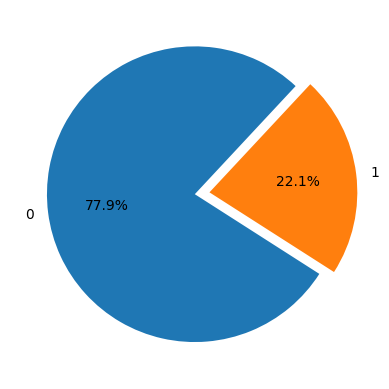

In [7]:
plt.pie(
    [y[y==0].shape[0], y[y==1].shape[0]],
    autopct='%1.1f%%',
    explode=(0, 0.1),
    labels=['0', '1'],
    startangle=47
)
plt.show();

In [8]:
unique, counts = np.unique(y, return_counts=True)
print(f"Класс 0 : {counts[0]}")
print(f"Класс 1 : {counts[1]}")

Класс 0 : 23322
Класс 1 : 6622


In [9]:
unique_counts = pd.DataFrame.from_records([(col, X[col].unique(), X[col].nunique(), X[col].dtypes) for col in X.columns],
                                          columns=['Name', 'Values', 'Count of values', 'Type']).sort_values(by=['Count of values', 'Name'])
unique_counts

,Name,Values,Count of values,Type
1,sex,"[2, 1]",2,int64
3,marriage,"[1, 2, 3, 0]",4,int64
2,education,"[2, 1, 3, 5, 4, 6, 0]",7,int64
9,pay_5,"[-2, 0, -1, 2, 3, 5, 4, 7, 8, 6]",10,int64
10,pay_6,"[-2, 2, 0, -1, 3, 6, 4, 7, 8, 5]",10,int64
5,pay_0,"[2, -1, 0, -2, 1, 3, 4, 8, 7, 5, 6]",11,int64
6,pay_2,"[2, 0, -1, -2, 3, 5, 7, 4, 1, 6, 8]",11,int64
7,pay_3,"[-1, 0, 2, -2, 3, 4, 6, 7, 1, 5, 8]",11,int64
8,pay_4,"[-1, 0, -2, 2, 3, 4, 5, 7, 6, 1, 8]",11,int64
4,age,"[24, 26, 34, 37, 57, 29, 23, 28, 35, 51, 41, 3...",56,int64


In [10]:
num_cols = ['bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4',
            'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3',
            'pay_amt4', 'pay_amt5', 'pay_amt6', 'age', 'limit_bal']
cat_cols = ['sex', 'education', 'marriage', 'pay_0', 'pay_2', 'pay_3',
            'pay_4', 'pay_5', 'pay_6']